<a href="https://colab.research.google.com/github/jre29/lecture1uep/blob/regresja/regresja_ZAD1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay

In [51]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
)

print("First 5 records:", df.head())

<ipython-input-51-9f69f8392d9a>:9: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  df = kagglehub.load_dataset(


First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [52]:
df.info()

le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  20

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               375 non-null    int64  
 2   Education Level      375 non-null    int64  
 3   Job Title            375 non-null    int64  
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 17.7 KB


Zbuduj model benchmarkowy - zwykłą regresję liniową

In [53]:
X = df.drop('Salary', axis=1)
y = df['Salary']

X = X.dropna()
y = y[X.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

print(X_train.info(), y_train.info())
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')


<class 'pandas.core.frame.DataFrame'>
Index: 298 entries, 193 to 102
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  298 non-null    float64
 1   Gender               298 non-null    int64  
 2   Education Level      298 non-null    int64  
 3   Job Title            298 non-null    int64  
 4   Years of Experience  298 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 14.0 KB
<class 'pandas.core.series.Series'>
Index: 298 entries, 193 to 102
Series name: Salary
Non-Null Count  Dtype  
--------------  -----  
298 non-null    float64
dtypes: float64(1)
memory usage: 4.7 KB
None None
Mean Squared Error: 249075656.42722148
R-squared: 0.8961138207821864


Sprawdź czy w danych występuje współliniowość współczynnikiem VIF

In [54]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

               feature        VIF
0                  Age  15.191310
1               Gender   2.059767
2      Education Level   2.403316
3            Job Title   4.865563
4  Years of Experience   9.479247


Spróbuj poprawić wynik używając regresji LASSO

Mean Squared Error: 249076954.18759638
R-squared: 0.8961132795034086
Współczynniki regresji Lasso: [ 3383.53816599  7274.79395129 15062.73320878    45.92371755
  2182.46326215]


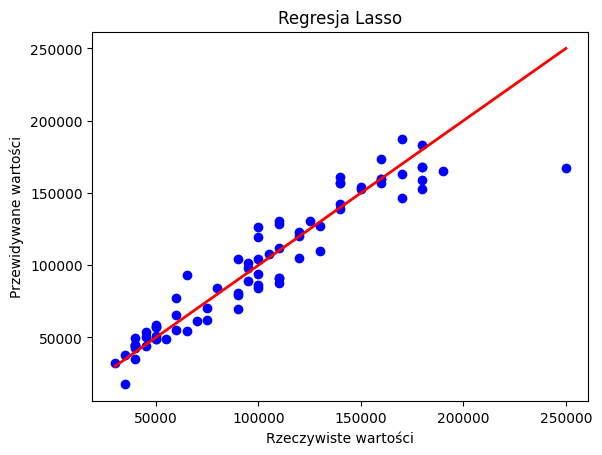

In [55]:
from sklearn.linear_model import Lasso

X = df.drop('Salary', axis=1)
y = df['Salary']

X = X.dropna()
y = y[X.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Lasso(alpha=0.1)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

print("Współczynniki regresji Lasso:", model.coef_)

plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Rzeczywiste wartości')
plt.ylabel('Przewidywane wartości')
plt.title('Regresja Lasso')
plt.show()


Zbuduj dodatkową zmienną, kwadrat lat doświadczenia, zbuduj ponownie regresję


Mean Squared Error: 253102107.02985275
R-squared: 0.8944344412116709
Współczynniki regresji Lasso: [ 3224.97909693  7488.36418641 15152.0294846     32.71077098
  3048.96044179   -31.09279516]


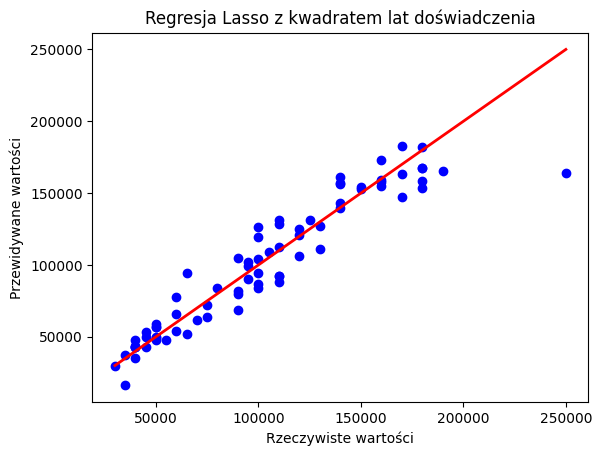

In [56]:
df['Experience_squared'] = df['Years of Experience'] ** 2

X = df.drop('Salary', axis=1)
y = df['Salary']

X = X.dropna()
y = y[X.index]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Lasso(alpha=0.1)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

print("Współczynniki regresji Lasso:", model.coef_)

plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Rzeczywiste wartości')
plt.ylabel('Przewidywane wartości')
plt.title('Regresja Lasso z kwadratem lat doświadczenia')
plt.show()


narysyj wykres typu scatterplot, dla zmiennych lata doswiadczenia i płaca, czy regresja wyższego rzędu jest uzasadniona?

Years of Experience    2
Salary                 2
dtype: int64


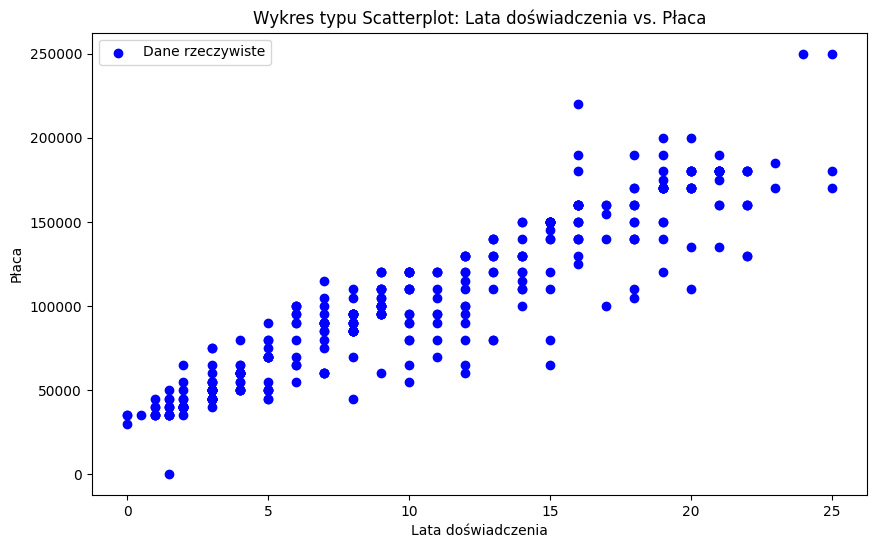

Model liniowy: MSE = 312090043.799001, R2 = 0.865528278393677
Model kwadratowy (2 rząd): MSE = 308112739.2458592, R2 = 0.8672419985242624


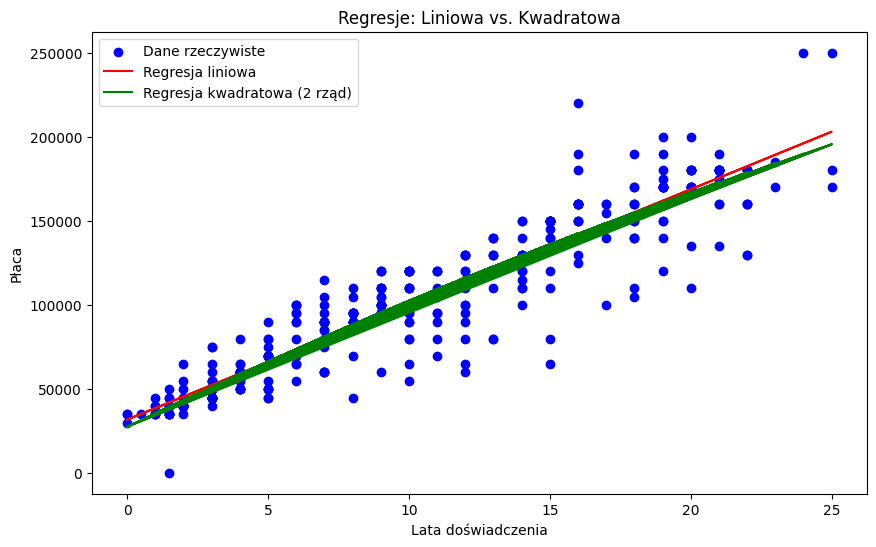

In [57]:
print(df[['Years of Experience', 'Salary']].isna().sum())

df = df.dropna(subset=['Years of Experience', 'Salary'])

plt.figure(figsize=(10, 6))
plt.scatter(df['Years of Experience'], df['Salary'], color='blue', label='Dane rzeczywiste')
plt.xlabel('Lata doświadczenia')
plt.ylabel('Płaca')
plt.title('Wykres typu Scatterplot: Lata doświadczenia vs. Płaca')
plt.legend()
plt.show()

X_linear = df['Years of Experience'].values.reshape(-1, 1)
y = df['Salary']

model_linear = LinearRegression()
model_linear.fit(X_linear, y)

y_pred_linear = model_linear.predict(X_linear)

X_quad = np.column_stack([df['Years of Experience'], df['Years of Experience']**2])
model_quad = LinearRegression()
model_quad.fit(X_quad, y)

y_pred_quad = model_quad.predict(X_quad)

mse_linear = mean_squared_error(y, y_pred_linear)
r2_linear = r2_score(y, y_pred_linear)

mse_quad = mean_squared_error(y, y_pred_quad)
r2_quad = r2_score(y, y_pred_quad)

print(f"Model liniowy: MSE = {mse_linear}, R2 = {r2_linear}")
print(f"Model kwadratowy (2 rząd): MSE = {mse_quad}, R2 = {r2_quad}")

plt.figure(figsize=(10, 6))
plt.scatter(df['Years of Experience'], df['Salary'], color='blue', label='Dane rzeczywiste')
plt.plot(df['Years of Experience'], y_pred_linear, color='red', label='Regresja liniowa')
plt.plot(df['Years of Experience'], y_pred_quad, color='green', label='Regresja kwadratowa (2 rząd)')
plt.xlabel('Lata doświadczenia')
plt.ylabel('Płaca')
plt.title('Regresje: Liniowa vs. Kwadratowa')
plt.legend()
plt.show()



Spróbuj wykorzystać regresje za pomocą K-NN
https://scikit-learn.org/stable/auto_examples/neighbors/plot_regression.html#sphx-glr-auto-examples-neighbors-plot-regression-py

In [60]:
from sklearn.neighbors import KNeighborsRegressor

df = df.dropna(subset=['Years of Experience', 'Salary'])

X = df['Years of Experience'].values.reshape(-1, 1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_linear = LinearRegression()
model_linear.fit(X_train, y_train)
y_pred_linear = model_linear.predict(X_test)

k_values = [1, 5, 10]
mse_knn = []
r2_knn = []

for k in k_values:
    model_knn = KNeighborsRegressor(n_neighbors=k)
    model_knn.fit(X_train, y_train)
    y_pred_knn = model_knn.predict(X_test)

    mse_knn.append(mean_squared_error(y_test, y_pred_knn))
    r2_knn.append(r2_score(y_test, y_pred_knn))

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Model liniowy: MSE = {mse_linear}, R2 = {r2_linear}")
for i, k in enumerate(k_values):
    print(f"Model K-NN (K={k}): MSE = {mse_knn[i]}, R2 = {r2_knn[i]}")


Model liniowy: MSE = 241834883.8999349, R2 = 0.8991338517367767
Model K-NN (K=1): MSE = 420000000.0, R2 = 0.8248235259224107
Model K-NN (K=5): MSE = 260253333.33333334, R2 = 0.8914517588088742
Model K-NN (K=10): MSE = 276078883.0, R2 = 0.8848511302590016
